#### Fixed Points + Hamming Analysis

In [ ]:
#import matplotlib.pyplot as plt
#import networkx as nx
#import matplotlib as mpl
#import pandas as pd
#import numpy as np
#import re
#import random as rn
#import warnings
#from tqdm import tqdm
#import os
#import glob
#from sklearn.cluster import DBSCAN, AgglomerativeClustering
#import networkx as nx
#import umap
#from sklearn.decomposition import PCA
#from sklearn.manifold import TSNE
#from scipy.cluster.hierarchy import dendrogram
#from joblib import Parallel, delayed
#from pathlib import Path
#from matplotlib.transforms import blended_transform_factory
#import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.pipeline import make_pipeline
#from sklearn.preprocessing import PolynomialFeatures
#from sklearn.linear_model import Ridge
#from matplotlib.colors import TwoSlopeNorm
#from scipy import stats
#import tqdm
#from itertools import combinations
#
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#
#warnings.filterwarnings("ignore")
#
#def Hamming_Distance(state1, state2):
#    if len(state1) != len(state2):
#        raise ValueError("The two states have different sizes\n")
#    ovlp = 0
#    for i in range(len(state1)):
#        ovlp = ovlp + state1.iloc[i] * state2.iloc[i]
#    ovlp = ovlp * (1/len(state1))
#    return (1 - ovlp)/2
#
#
#
#def weights_cluster(data, W, m = None, s = 0.5):
#    if isinstance(W, float):
#        W = [W]
#
#    compressor = umap.UMAP()
#    to_umap_instances = []
#    colors = []
#    for W_val in tqdm(W):
#        for rep in data["Rep"].unique():
#
#            fname = f"Weights_rep={rep}_W={W_val:.3f}_k=1.000_eta_w=1.000_eta_s=1.000.csv"
#            w = pd.read_csv(fname, header=None).to_numpy()
#            w = w[np.triu_indices(w.shape[0], k=1)]
#            to_umap_instances.append(w)
#
#            if (m != None):
#                colors.append(data.iloc[(data["W"] == W_val) & (data["Rep"] == rep),2].to_numpy() > m)
#            else:
#                colors.append(W_val * 20)
#
#    embedding = compressor.fit_transform(to_umap_instances)
#
#    plt.scatter(embedding[:, 0],embedding[:, 1], c = colors, s = s)
#    plt.title('UMAP projection of the Weights Space')
#
#
#
#
#def weight_print(data, fn):
#    rep = fn.split("_")[1].split("=")[1]
#    W = fn.split("_")[2].split("=")[1]
#
#    weights  = pd.read_csv(fn, header=None)
#    M = np.abs(weights.to_numpy()).max()
#    norm = TwoSlopeNorm(vmin=-M, vcenter=0, vmax=M)
#
#    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
#
#    im0 = ax[0].imshow(weights, cmap="coolwarm", norm=norm)
#    fig.colorbar(im0, ax=ax[0])
#    ax[0].set_title("Weights")
#
#    im1 = ax[1].imshow(np.array(weights >= 0, int) - np.array(weights <= 0, int), cmap="gray")
#    fig.colorbar(im1, ax=ax[1])
#    ax[1].set_title("Weights Sign")
#
#    plt.tight_layout()
#    plt.show()
#    print(f"Fixed Points: {data.loc[(data['Rep'] == float(rep)) & (data['W'] == float(W)), 'Fixed Points'].iloc[0]}")
#    print(f"Portion of positive synapses: {np.sum(weights > 0)/(weights.shape[0]**2)}")
#    print("Min:", weights.to_numpy().min())
#    print("Max:", weights.to_numpy().max())
#    print("Max - Min:", weights.to_numpy().max() - weights.to_numpy().min())
#    print("Mean:", weights.to_numpy().mean())
#    print("Std:", weights.to_numpy().std())
#    print("Mean absolute difference from mean:", np.abs(weights.to_numpy() - weights.to_numpy().mean()).mean())

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import re
import random as rn
import warnings
from tqdm import tqdm
import os
import glob
from sklearn.cluster import DBSCAN, AgglomerativeClustering
import networkx as nx
#import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram
from joblib import Parallel, delayed
from pathlib import Path
from matplotlib.transforms import blended_transform_factory
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import tqdm
from itertools import combinations


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
data = pd.read_csv("Data.csv")
data["cycle_fraction"] = data["cycles_runs"] / 100
print(data)

         N    W    k  ETA_w  ETA_s  fp_runs  cycles_runs  max_steps_runs  \
0     1000  0.0  100    0.0   0.00        0            0             100   
1     1000  0.0  100    0.0   0.05        0            0             100   
2     1000  0.0  100    0.0   0.10        0            0             100   
3     1000  0.0  100    0.0   0.15        0            0             100   
4     1000  0.0  100    0.0   0.20        0            0             100   
...    ...  ...  ...    ...    ...      ...          ...             ...   
4846  1000  0.5  100    1.0   0.80        0          100               0   
4847  1000  0.5  100    1.0   0.85        0          100               0   
4848  1000  0.5  100    1.0   0.90        0          100               0   
4849  1000  0.5  100    1.0   0.95        0          100               0   
4850  1000  0.5  100    1.0   1.00        0          100               0   

      fixed_points  updates  hamming  cycle_fraction  
0                0        0     

In [53]:
data.iloc[:, 5].sum()

np.int64(0)

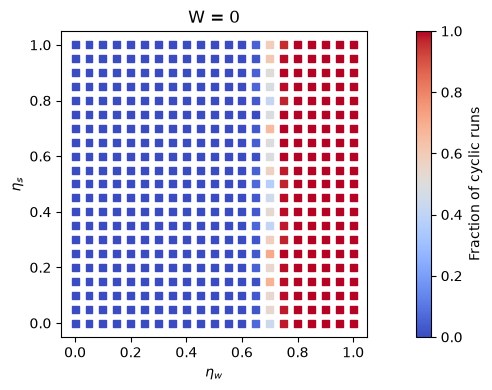

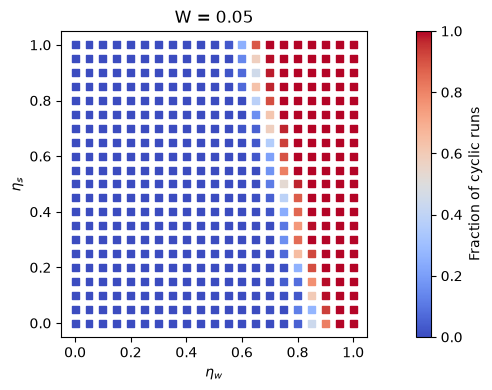

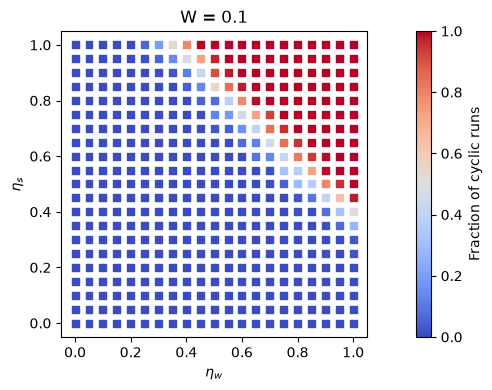

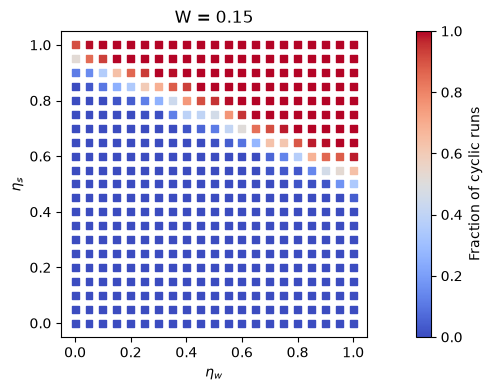

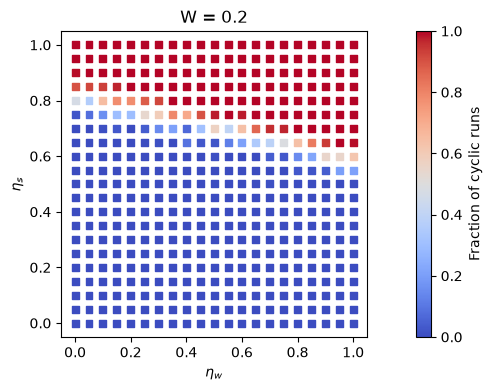

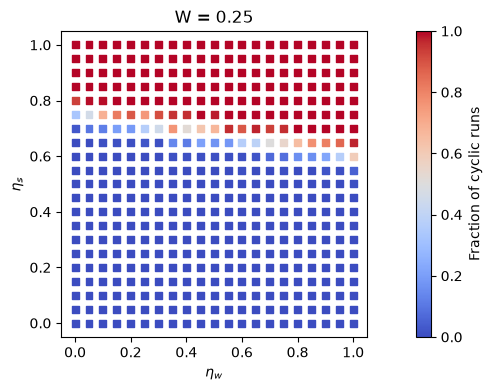

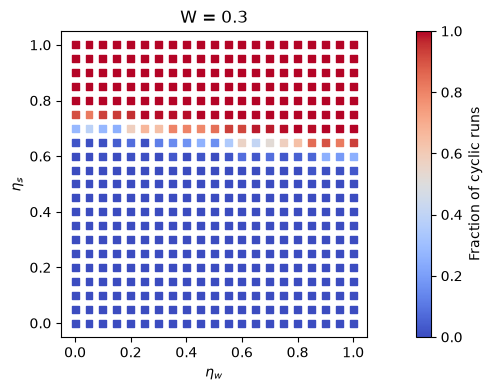

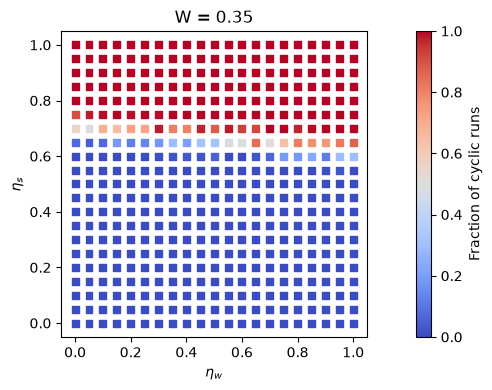

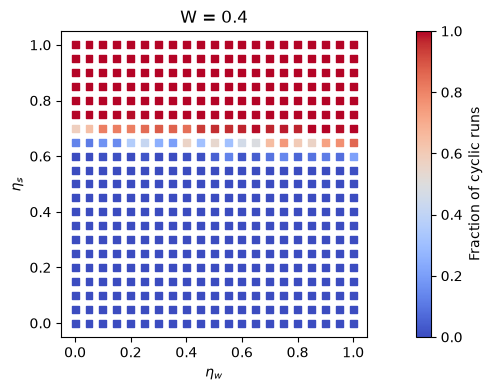

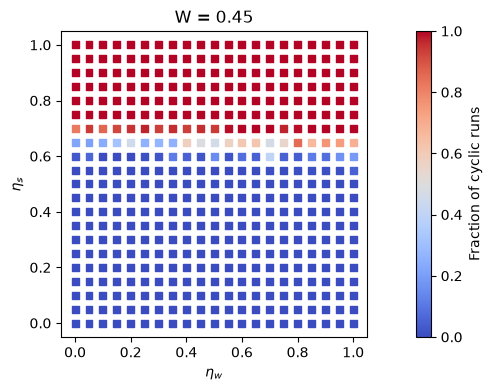

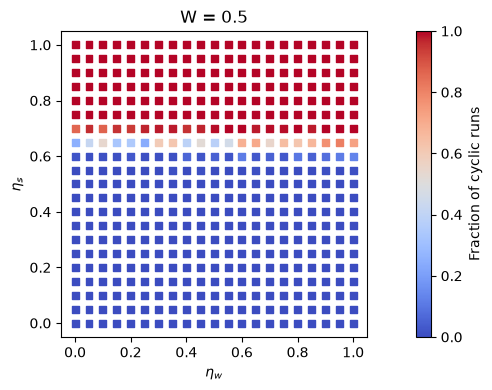

In [54]:
w_values = np.sort(data["W"].unique())

for W in w_values:
    d = data[data["W"] == W]

    fig, ax = plt.subplots(figsize=(10, 4))

    sc = ax.scatter(
        d["ETA_w"],
        d["ETA_s"],
        c=d["cycle_fraction"],
        marker="s",
        s=25,
        cmap="coolwarm"
    )

    ax.set_title(f"W = {W:g}")
    ax.set_xlabel(r"$\eta_w$")
    ax.set_ylabel(r"$\eta_s$")
    ax.set_xticks(np.arange(0, 1.2, 0.2))
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.set_aspect("equal")

    fig.colorbar(
        sc,
        ax=ax,
        label="Fraction of cyclic runs"
    )

    plt.tight_layout()
    plt.show()

0      6
1      3
2      4
3      1
4      1
      ..
995    1
996    4
997    7
998    6
999    2
Length: 1000, dtype: int64


49     0
52     0
151    0
157    0
245    0
292    0
323    0
350    0
404    0
448    0
497    0
632    0
635    0
649    0
667    0
776    0
857    0
933    0
966    0
Name: 0, dtype: int64


19




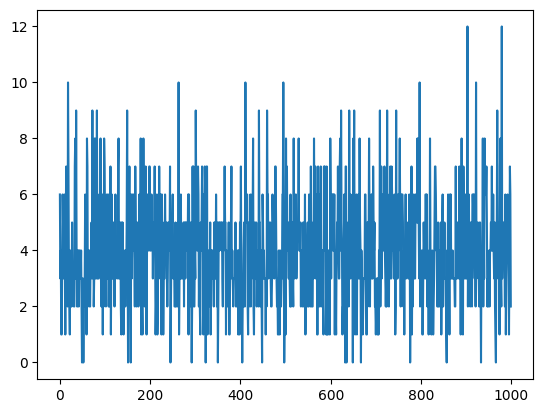

In [ ]:
#w = pd.read_csv("Weights.csv", header=None)
#w_strong = pd.read_csv("StrongWeights.csv", header=None)
#print(w_strong.sum())
#print("\n")
#print(w_strong.iloc[w_strong.sum() == 0,0])
#print("\n")
#print(len(w_strong.iloc[w_strong.sum() == 0,0]))
#print("\n")
#plt.plot(w_strong.sum())

In [ ]:
#np.sum(w_strong)

np.int64(3996)

In [ ]:
#fps = pd.read_csv("FixedPoints.csv", header=None)

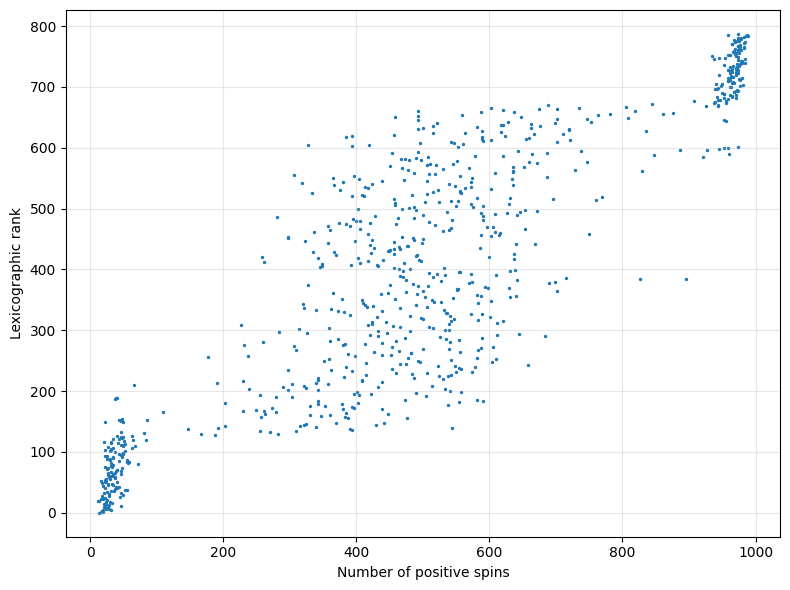

In [ ]:
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#
#
#def plot_fixed_points_lexicographic(fixed_points_df, figsize=(8, 6), s=2):
#
#    states = fixed_points_df.to_numpy()
#
#    x = np.sum(states == 1, axis=1)
#
#    lex_keys = [
#        tuple(row)
#        for row in states
#    ]
#
#    ordered_indices = sorted(range(len(lex_keys)), key=lambda i: lex_keys[i])
#
#    y = np.empty(len(ordered_indices), dtype=int)
#    for rank, idx in enumerate(ordered_indices):
#        y[idx] = rank
#
#    plt.figure(figsize=figsize)
#    plt.scatter(x, y, s=s)
#
#    plt.xlabel("Number of positive spins")
#    plt.ylabel("Lexicographic rank")
#    #plt.title("Positive spins vs Lexicographic order")
#    #plt.vlines(40, 0, len(lex_keys), color = "black", linestyles="--")
#    #plt.vlines(960, 0, len(lex_keys), color = "black", linestyles="--")
#
#    plt.grid(alpha=0.3)
#    plt.tight_layout()
#    plt.show()
#
#plot_fixed_points_lexicographic(fps)

In [ ]:
#dist_list = []
#close_list = []
#far_list = []
#
#dist_threshold = 100
#
#for i in tqdm.tqdm(range(fps.shape[0])):
#    for j in range(i, fps.shape[0]):
#        if (fps.iloc[i,:] == fps.iloc[j,:]).all():
#            continue
#        dist_list.append((fps.iloc[i,:] != fps.iloc[j,:]).sum())
#        if (fps.iloc[i,:] != fps.iloc[j,:]).sum() < 200:
#            close_list.append((i,j))
#        if (fps.iloc[i,:] != fps.iloc[j,:]).sum() > (1000 - dist_threshold):
#            far_list.append((i,j))

In [ ]:
#close_df = pd.DataFrame(close_list, columns=["source", "target"])
#close_df.to_csv("close_list.csv", index=False)
#dist_df = pd.DataFrame(dist_list)
#dist_df.to_csv("dist_list.csv", index=False)
#far_df = pd.DataFrame(far_list, columns=["source", "target"])
#far_df.to_csv("far_list.csv", index=False)

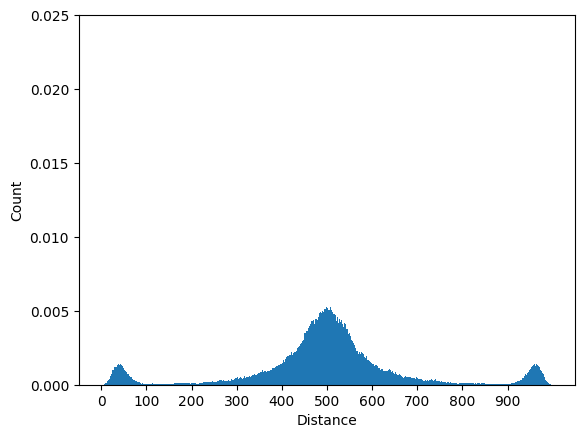

In [ ]:
dist_list = pd.read_csv("dist_list.csv")
density = data.iloc[0,5] * (data.iloc[0,5] - 1) / 2
bins = np.arange(0, 1000, 1)
plt.hist(dist_list, bins = bins, weights=np.ones(len(dist_list)) / density)
#plt.title("Hamming Distances between fixed points")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.ylim(0, 0.025)
plt.xticks(np.arange(0, 1000, 100))
plt.show()

In [ ]:
close_df = pd.read_csv("close_list.csv")
close_list = list(close_df.itertuples(index=False, name=None))


G = nx.Graph()

G.add_edges_from(close_list)

components = list(nx.connected_components(G))

print([len(c) for c in components])

for i, comp in enumerate(components):
    print(f"Componente {i}: size={len(comp)}, nodi={comp}")

[141, 129]
Componente 0: size=141, nodi={0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 131, 132, 149, 150, 151, 152, 153, 154, 165, 187, 188, 189, 210}
Componente 1: size=129, nodi={584, 590, 596, 597, 598, 599, 600, 601, 644, 645, 668, 669, 670, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726,

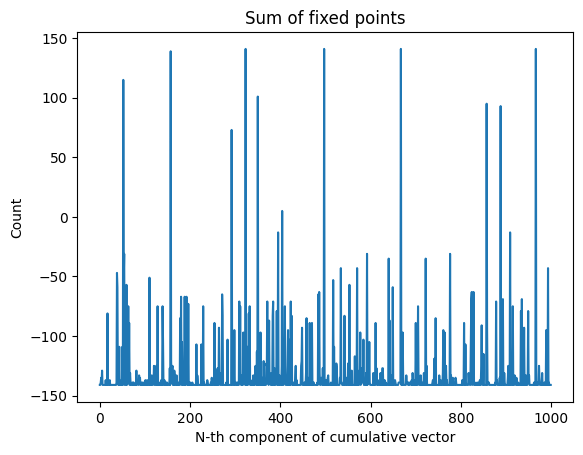

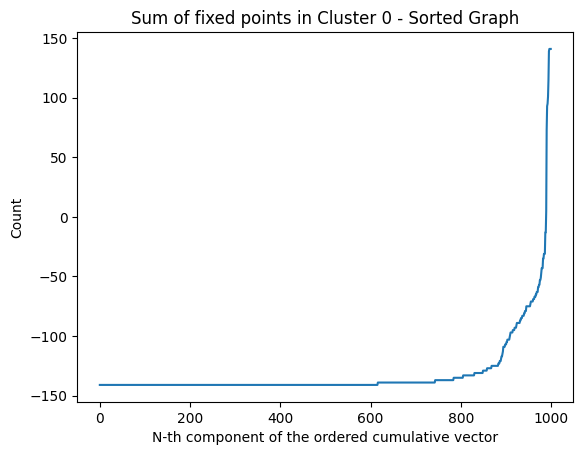

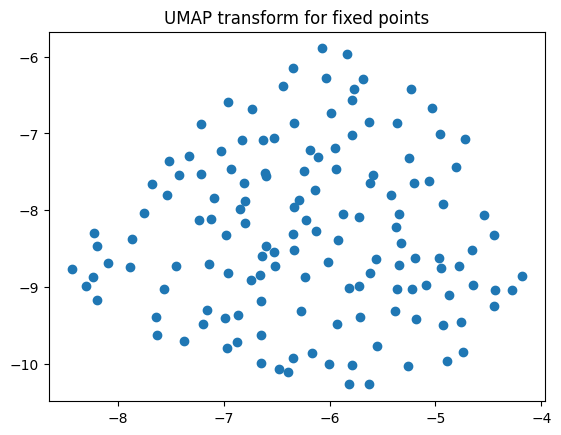

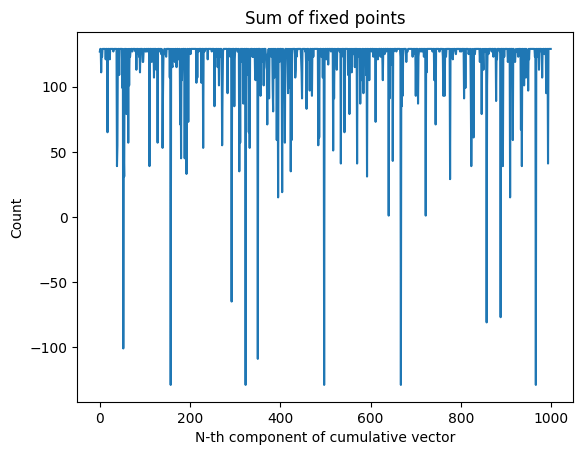

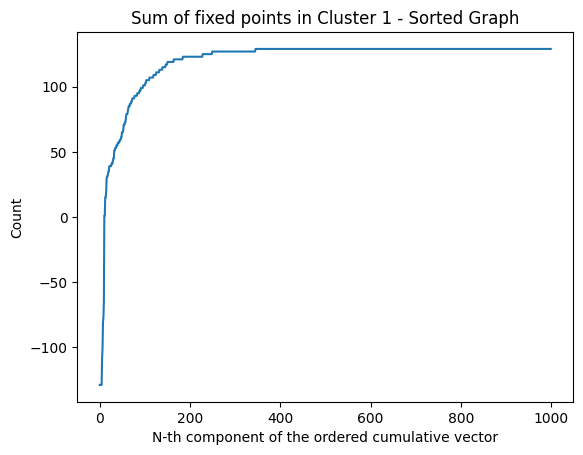

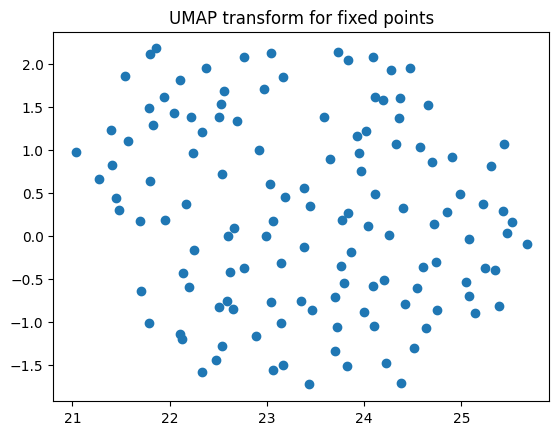

In [ ]:
reducer = umap.UMAP()

for i, comp in enumerate(components):
    base = np.zeros(shape=(1000,))
    sort_base = np.zeros(shape=(1000,))
    embedding_list = []
    for j in comp:
        base += np.array(fps.iloc[j,:])
        sort_base += np.array(fps.iloc[j,:])
        embedding_list.append(j)
    sort_base = sorted(sort_base)
    
    embedding = reducer.fit_transform(fps.iloc[embedding_list,:])

    plt.plot(base)
    plt.title("Sum of fixed points")
    plt.xlabel("N-th component of cumulative vector")
    plt.ylabel("Count")
    plt.show()

    plt.plot(sort_base)
    plt.title(f"Sum of fixed points in Cluster {i} - Sorted Graph")
    plt.xlabel("N-th component of the ordered cumulative vector")
    plt.ylabel("Count")
    plt.show()

    plt.scatter(embedding[:, 0],embedding[:, 1])
    plt.title("UMAP transform for fixed points")
    plt.show()

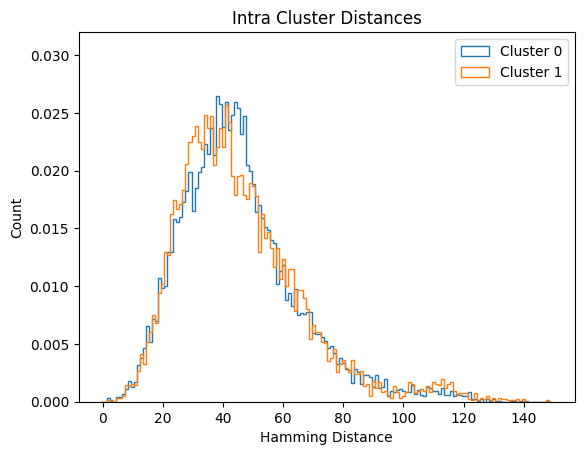

In [ ]:
for i, comp in enumerate(components):
    intra_cluster_distance = []
    for j, k in combinations(comp, 2):
        intra_cluster_distance.append((fps.iloc[j,:] != fps.iloc[k,:]).sum())

    plt.hist(intra_cluster_distance, bins=np.arange(-0.5, 150.5, 1),
        histtype="step", linewidth=1, label=f"Cluster {i}", weights=np.ones(len(intra_cluster_distance)) / len(intra_cluster_distance))
plt.title(f"Intra Cluster Distances")
plt.xlabel("Hamming Distance")
plt.ylabel("Count")
plt.ylim(0,0.032)
plt.legend()
plt.show()

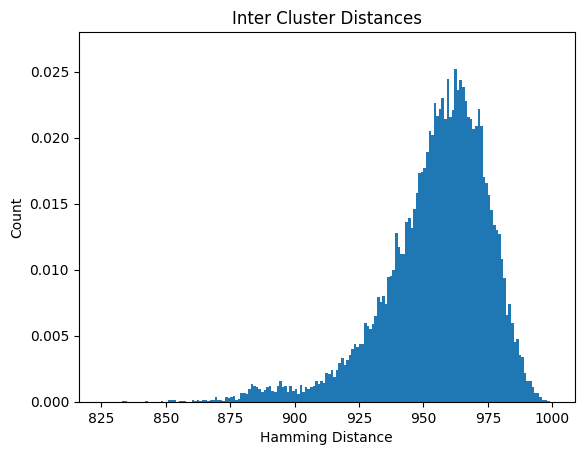

In [ ]:
inter_layer_dist_list = []

if len(components) != 0:
    for i in components[0]:
        for j in components[1]:
            inter_layer_dist_list.append((fps.iloc[i,:] != fps.iloc[j,:]).sum())

plt.hist(inter_layer_dist_list, bins = np.linspace(825, 1000, 176), weights=np.ones(len(inter_layer_dist_list)) / len(inter_layer_dist_list))
plt.title(f"Inter Cluster Distances")
plt.xlabel("Hamming Distance")
plt.ylabel("Count")
plt.ylim(0,0.028)
plt.show()

In [ ]:
stability_list = []

for i in range(fps.shape[0]):
    temp_stab = (w @ fps.iloc[i,:]) * fps.iloc[i,:]
    for stab in temp_stab:
        stability_list.append(stab)

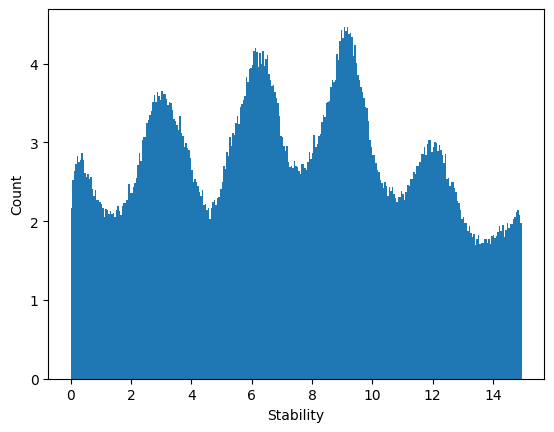

In [ ]:
plt.hist(stability_list, bins = np.arange(0, 15, 0.05), weights=np.ones(len(stability_list)) / data.iloc[0,5])
#plt.title("Stability of fixed points")
plt.xlabel("Stability")
plt.ylabel("Count")
#plt.ylim(0, 30)
plt.show()

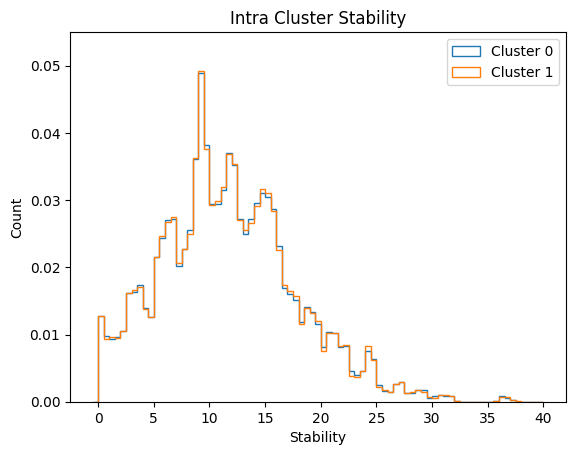

In [ ]:
for i, comp in enumerate(components):
    intra_cluster_stability = []
    for j in comp:
        temp_stab = (w @ fps.iloc[j,:]) * fps.iloc[j,:]
        for stab in temp_stab:
            intra_cluster_stability.append(stab)
    plt.hist(intra_cluster_stability, bins=np.arange(-0.5, 40.5, 0.5),
        histtype="step", linewidth=1, label=f"Cluster {i}", weights=np.ones(len(intra_cluster_stability)) / len(intra_cluster_stability))


plt.title(f"Intra Cluster Stability")
plt.xlabel("Stability")
plt.ylabel("Count")
plt.legend()
plt.ylim(0,0.055)
plt.show()

In [ ]:
#count = {}
#
#for ind in tqdm.tqdm(range(fps.shape[0])):
#    for i in range(w_strong.shape[0]):
#        for j in range(i, w_strong.shape[0]):
#            if w_strong.iloc[i,j] == 1  and (fps.iloc[ind,i] == fps.iloc[ind,j]):
#                if ind in count:
#                    count[ind] += 1
#                else:
#                    count[ind] = 1
#
#pd.DataFrame(count.items(), columns=["key", "count"]).to_csv("count.csv", index=False)




#CODE TOO LONG FOR LIVE RUN; IMPORT "count.csv"

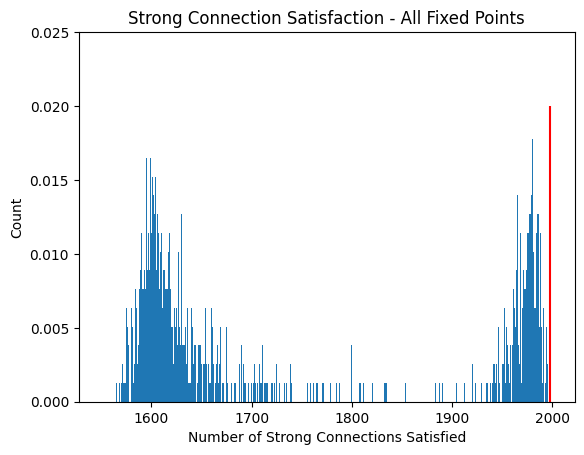

In [ ]:
count = pd.read_csv("count.csv")
plt.hist(count.iloc[:,1], bins = np.linspace(1550, 2000, 451), weights=np.ones(len(count.iloc[:,1])) / len(count.iloc[:,1]))
plt.vlines(np.sum(w_strong)/2, 0, 0.02, "red", label = "Strong Connections")
plt.title("Strong Connection Satisfaction - All Fixed Points")
plt.xlabel("Number of Strong Connections Satisfied")
plt.ylabel("Count")
plt.ylim(0,0.025)
plt.show()

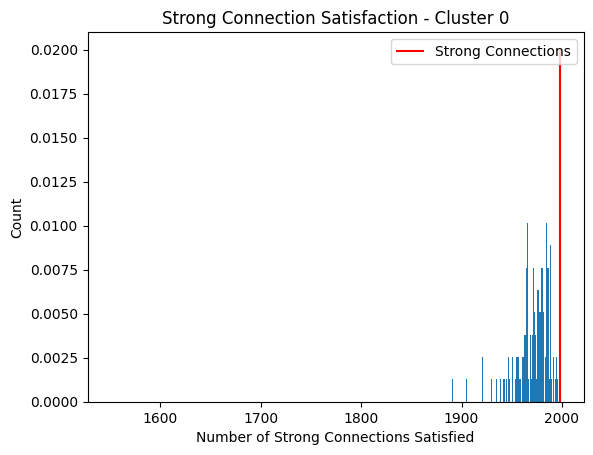

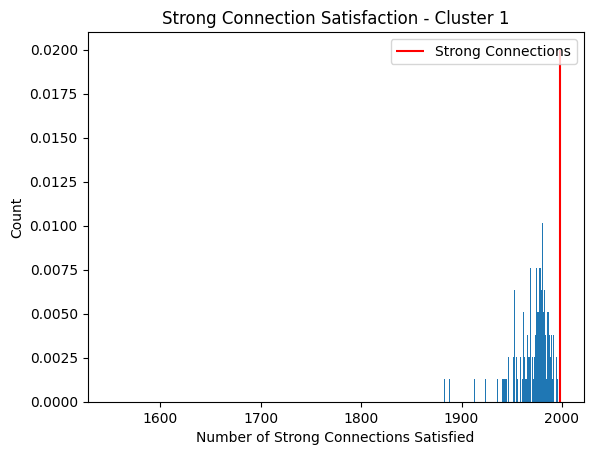

In [ ]:
count = pd.read_csv("count.csv")
for i, comp in enumerate(components):
    temp_list = [count.iloc[j,1] for j in comp]
    plt.hist(temp_list, bins = np.arange(1550, 2000, 1), weights=np.ones(len(temp_list)) / len(count.iloc[:,1]))
    plt.vlines(np.sum(w_strong)/2, 0, 0.02, "red", label = "Strong Connections")
    plt.title(f"Strong Connection Satisfaction - Cluster {i}")
    plt.xlabel("Number of Strong Connections Satisfied")
    plt.ylabel("Count")
    plt.legend()
    plt.ylim()
    plt.show()

Original clusters are 141, 129 points

First cluster: 141 -> 149 -> 

In [ ]:
comp0 = components[0]
cluster0 = fps.iloc[list(comp0),:].copy()
comp1 = components[1]
cluster1 = fps.iloc[list(comp1),:].copy()

In [ ]:
def count_points_at_dist(cluster_df, max_hamming_dist_plot):

    T = nx.Graph()

    for i in range(cluster_df.shape[0]):
        for j in range(i + 1, cluster_df.shape[0]):
            distance = (cluster_df.iloc[i, :] != cluster_df.iloc[j, :]).sum()
            if 0 < distance and distance <= max_hamming_dist_plot:
                T.add_edge(i, j, weight=distance)

    MST_T = nx.minimum_spanning_tree(T)
    return len(MST_T.nodes())

In [ ]:
points_at_dist0 = []
points_at_dist1 = []

for i in tqdm.tqdm(range(101)):
    points_at_dist0.append(count_points_at_dist(cluster0, i)/len(cluster0))
for i in tqdm.tqdm(range(101)):
    points_at_dist1.append(count_points_at_dist(cluster1, i)/len(cluster1))

100%|██████████| 101/101 [00:46<00:00,  2.19it/s]


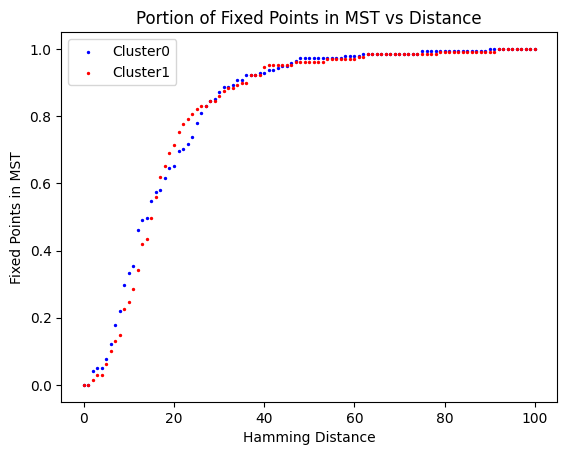

In [ ]:
plt.scatter(np.arange(0,101,1), points_at_dist0, s = 2, c = "blue", label= "Cluster0")
plt.scatter(np.arange(0,101,1), points_at_dist1, s = 2, c = "red", label= "Cluster1")
plt.title("Portion of Fixed Points in MST vs Distance")
plt.xlabel("Hamming Distance")
plt.ylabel("Fixed Points in MST")
plt.legend()
plt.show()

In [ ]:
def plot_radial_mst(eta_w, eta_s, W, k, cluster_df, max_hamming_dist_plot, cluster_name, figsize = (10,10), 
                    save = False, save_w = False, save_d = False):
    
    eta_w = str(eta_w)
    eta_s = str(eta_s)

    T = nx.Graph()

    for i in range(cluster_df.shape[0]):
        for j in range(i + 1, cluster_df.shape[0]):
            distance = (cluster_df.iloc[i, :] != cluster_df.iloc[j, :]).sum()
            if 0 < distance and distance <= max_hamming_dist_plot:
                T.add_edge(i, j, weight=distance)

    MST_T = nx.minimum_spanning_tree(T)

    dist = dict(nx.all_pairs_dijkstra_path_length(MST_T, weight="weight"))
    pos = nx.kamada_kawai_layout(MST_T, dist=dist)

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(MST_T, pos, node_size=30)
    nx.draw_networkx_edges(MST_T, pos, width=1)

    edge_labels = nx.get_edge_attributes(MST_T, "weight")
    nx.draw_networkx_edge_labels(
        MST_T,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        label_pos=0.5,
        rotate=True,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.15)
    )

    plt.axis("off")
    plt.tight_layout()
    plt.title(f"MST inside distance {max_hamming_dist_plot} - "
              f"Cluster {cluster_name} - Present Points {len(MST_T.nodes())}/{cluster_df.shape[0]} - Conn.Comp. {nx.number_connected_components(MST_T)}")
    

    filename = f"MST_cluster{cluster_name}_d={max_hamming_dist_plot}_1000_{eta_w[2:]+"0" if len(eta_w) > 1 else eta_w}_{eta_s[2:]+"0" if len(eta_s) > 1 else eta_s}_{W}_{k}"
    if save:
        plt.savefig(f"../../Cluster Analysis/FP_1000_{eta_w[2:]+"0" if len(eta_w) > 1 else eta_w}_{eta_s[2:]+"0" if len(eta_s) > 1 else eta_s}_{W}_{k}/{filename}.png", 
                    dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()




    bins = np.arange(-0.5, max_hamming_dist_plot + 1.5, 1)
    ticks = np.arange(0, max_hamming_dist_plot + 1, 2)
        
    weights = [d["weight"] for _, _, d in MST_T.edges(data=True)]
    plt.figure(figsize=(8,6))
    plt.hist(weights, bins=bins, rwidth=0.9)
    plt.xlabel("Distance")
    plt.xticks(ticks, fontsize=7)
    plt.ylabel("Count")
    plt.title(f"MST - Cluster{cluster_name} - d = {max_hamming_dist_plot} - Distances")
    if save_w:
        plt.savefig(f"../../Cluster Analysis/FP_1000_{eta_w[2:]+"0" if len(eta_w) > 1 else eta_w}_{eta_s[2:]+"0" if len(eta_s) > 1 else eta_s}_{W}_{k}/{filename}_distance.png",
                     dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

    degrees = [d for _, d in MST_T.degree()]
    plt.figure(figsize=(8,6))
    plt.hist(degrees, bins = np.arange(-0.5, max(degrees) + 1.5, 1), rwidth=0.9)
    plt.xlabel("Degree")
    plt.xticks(np.arange(0, max(degrees) + 1, 1), fontsize=7)
    plt.ylabel("Count")
    plt.title(f"MST - Cluster{cluster_name} - d = {max_hamming_dist_plot} - Degrees")
    if save_d:
        plt.savefig(f"../../Cluster Analysis/FP_1000_{eta_w[2:]+"0" if len(eta_w) > 1 else eta_w}_{eta_s[2:]+"0" if len(eta_s) > 1 else eta_s}_{W}_{k}/{filename}_degrees.png",
                     dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

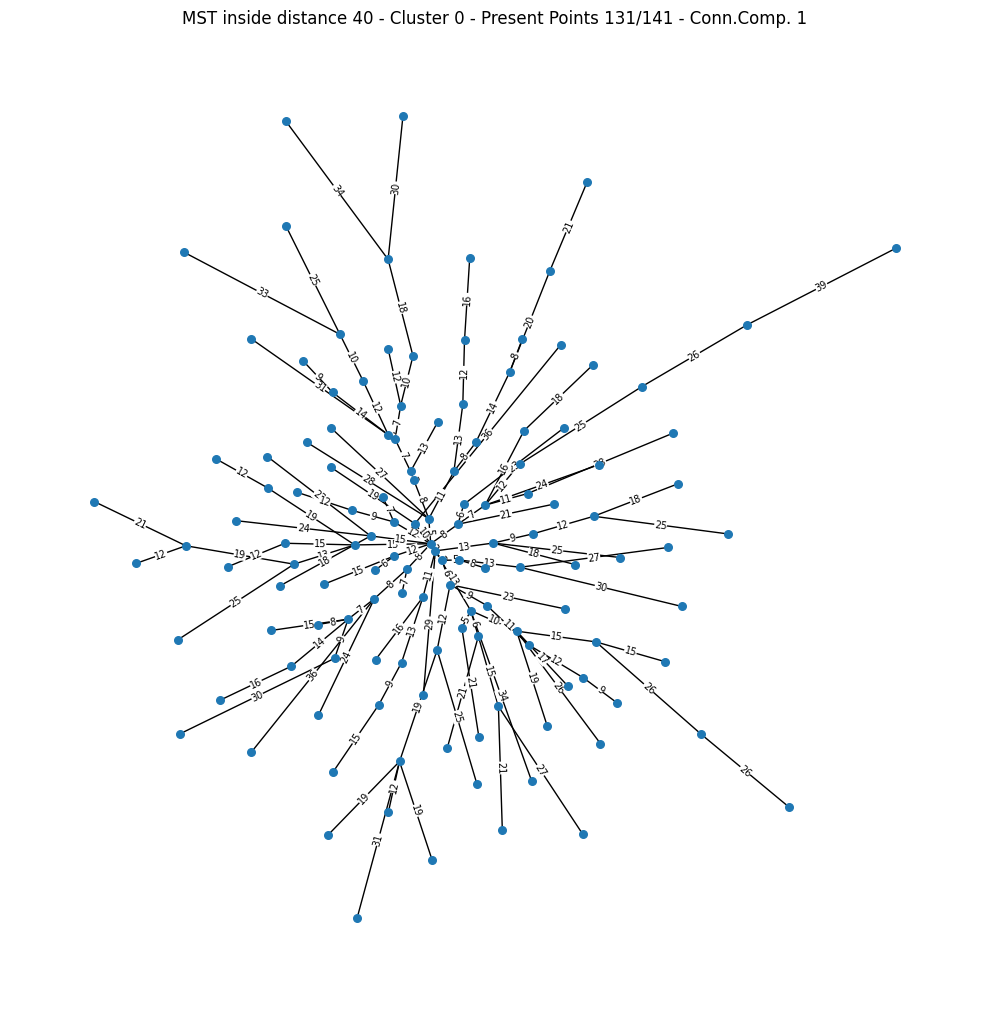

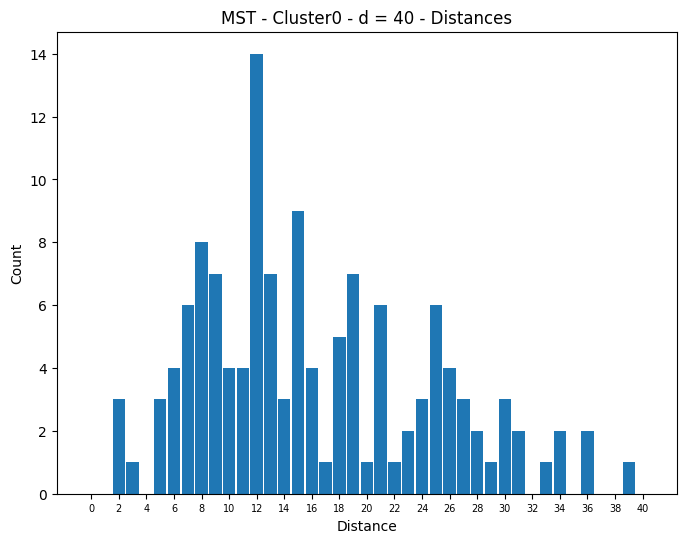

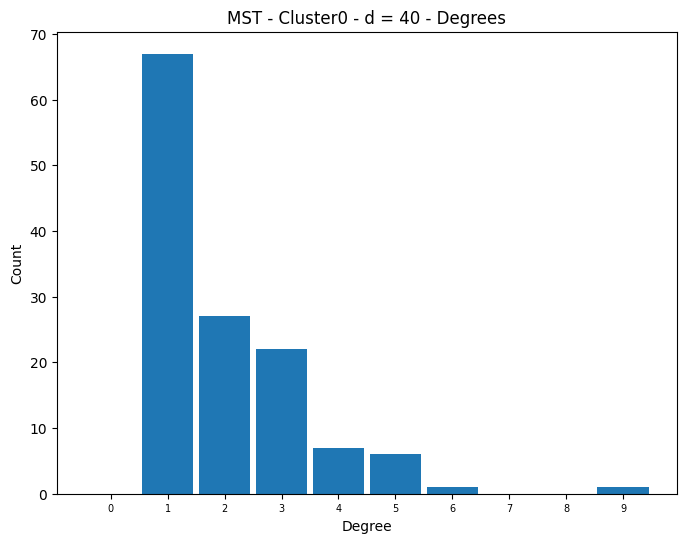

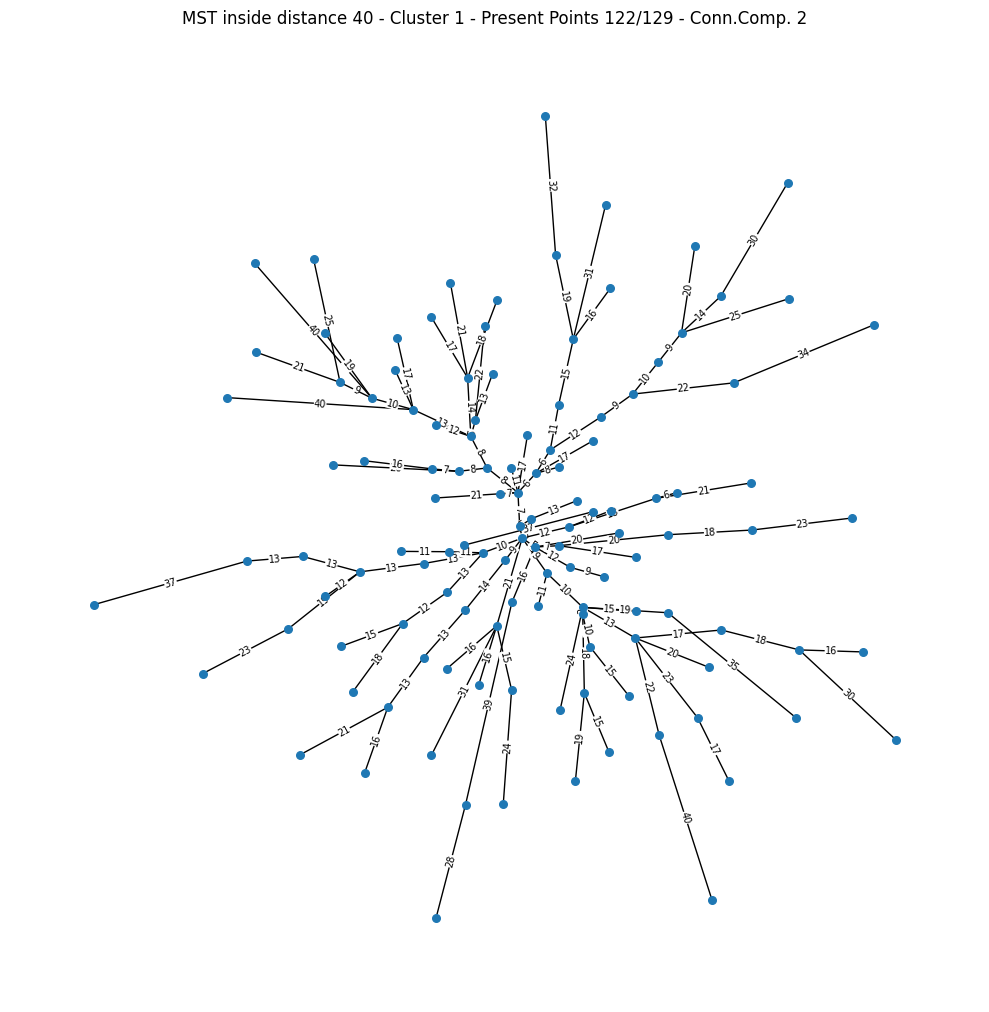

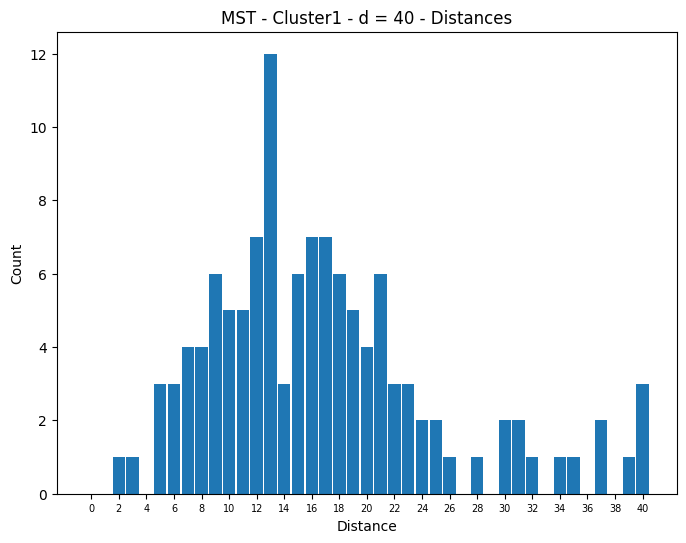

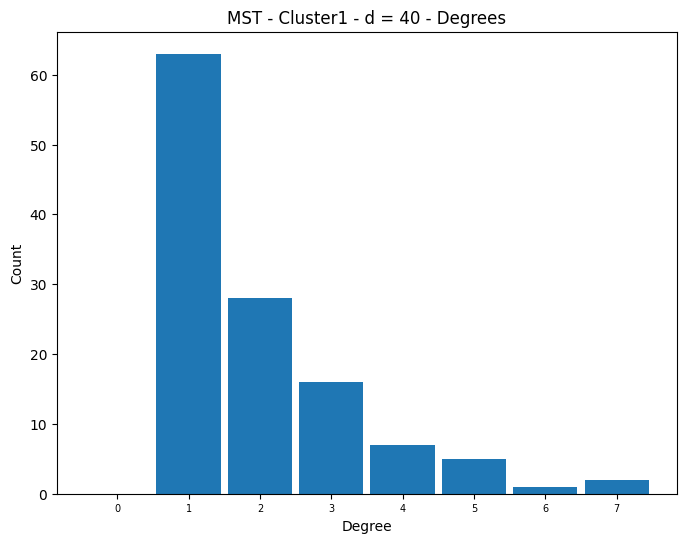

In [ ]:
save = True

plot_radial_mst(0, 1, 3, 4, cluster0,40,0,save=save,save_w=save,save_d=save)
plot_radial_mst(0, 1, 3, 4, cluster1,40,1,save=save,save_w=save,save_d=save)